# Análisis de matrices de atención en un Transformer encoder-only (BERT)

**Corpus:** *La Metamorfosis*, Franz Kafka — dos páginas consecutivas (ver `corpus_metamorfosis.txt`).

**Modelo:** `bert-base-multilingual-cased` (12 capas, 12 cabezas).

- Edwin de Leon 22809

## Instalación

In [1]:
!pip install -q transformers torch pandas matplotlib

In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

MODEL_NAME = 'bert-base-multilingual-cased'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Dispositivo:', DEVICE)

Dispositivo: cpu


## 4. Corpus (dos páginas consecutivas)



In [3]:
paginas = '''Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto.
Estaba tumbado sobre su espalda dura, y en forma de caparazón y, al levantar un poco la cabeza, veía un vientre abombado, parduzco, dividido por partes duras en forma de arco, sobre cuya prominencia apenas podía mantenerse el cobertor, a punto ya de resbalar al suelo.
Sus muchas patas, ridículamente pequeñas en comparación con el resto de su tamaño, le vibraban desamparadas ante los ojos.
Su habitación, una auténtica habitación humana, si bien algo pequeña, permanecía tranquila entre las cuatro paredes harto conocidas.
La mirada de Gregorio se dirigió después hacia la ventana, y el tiempo lluvioso lo puso muy melancólico.
Y cuando dieron las seis y cuarto se oyó que llamaban cautelosamente a la puerta que había junto a la cabecera de su cama.'''

# Intentamos leer el archivo del corpus si existe (tiene el texto completo de las 2 páginas).
try:
    with open('corpus_metamorfosis.txt', encoding='utf-8') as f:
        print(f.read()[:1500], '...')
except FileNotFoundError:
    print('(No se encontró corpus_metamorfosis.txt; se usa el texto embebido en la variable `paginas`.)')

# Oraciones lingüísticas que analizaremos (una simple, varias complejas).
oraciones = {
    'O1_simple':   'La mirada de Gregorio se dirigió hacia la ventana.',
    'O2_compleja': 'Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto.',
    'O3_compleja': 'Y cuando dieron las seis y cuarto se oyó que llamaban cautelosamente a la puerta que había junto a la cabecera de su cama.',
    # Par de contraste para la Parte D (palabra ambigua: "banco").
    'B1_banco_finanzas': 'El banco aprobó el préstamo.',
    'B2_banco_parque':   'Me senté en el banco del parque.',
}
for k, v in oraciones.items():
    print(f'{k:20s} | {v}')

(No se encontró corpus_metamorfosis.txt; se usa el texto embebido en la variable `paginas`.)
O1_simple            | La mirada de Gregorio se dirigió hacia la ventana.
O2_compleja          | Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto.
O3_compleja          | Y cuando dieron las seis y cuarto se oyó que llamaban cautelosamente a la puerta que había junto a la cabecera de su cama.
B1_banco_finanzas    | El banco aprobó el préstamo.
B2_banco_parque      | Me senté en el banco del parque.


## Parte A · Tokenización

Cargamos el tokenizer y mostramos los tokens de cada oración. Identificamos:
- Tokens especiales `[CLS]` y `[SEP]`.
- Palabras divididas en subpalabras (prefijo `##`).
- Diferencia entre **palabra lingüística** y **token del modelo**.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('Vocabulario:', tokenizer.vocab_size)
print('Especiales:', tokenizer.all_special_tokens)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

Vocabulario: 119547
Especiales: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [5]:
def inspeccionar_tokens(texto):
    enc = tokenizer(texto, return_tensors='pt')
    ids = enc['input_ids'][0].tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    word_ids = enc.word_ids()
    filas = []
    for i, (t, wid, tid) in enumerate(zip(toks, word_ids, ids)):
        filas.append({
            'idx': i,
            'token': t,
            'id': tid,
            'palabra_ling_#': wid,
            'especial': t in tokenizer.all_special_tokens,
            'subpalabra': t.startswith('##'),
        })
    return enc, toks, pd.DataFrame(filas)

for nombre, texto in oraciones.items():
    print('=' * 90)
    print(nombre, '::', texto)
    _, toks, df = inspeccionar_tokens(texto)
    print('N.º de tokens del modelo:', len(toks))
    print('Tokens:', toks)
    display(df)

O1_simple :: La mirada de Gregorio se dirigió hacia la ventana.
N.º de tokens del modelo: 14
Tokens: ['[CLS]', 'La', 'mira', '##da', 'de', 'Gregorio', 'se', 'dirigió', 'hacia', 'la', 'venta', '##na', '.', '[SEP]']


,idx,token,id,palabra_ling_#,especial,subpalabra
0,0,[CLS],101,NaN,True,False
1,1,La,10159,0.0,False,False
2,2,mira,51259,1.0,False,False
3,3,##da,10229,1.0,False,True
4,4,de,10104,2.0,False,False
5,5,Gregorio,36167,3.0,False,False
6,6,se,10126,4.0,False,False
7,7,dirigió,60342,5.0,False,False
8,8,hacia,15483,6.0,False,False
9,9,la,10109,7.0,False,False


O2_compleja :: Cuando Gregorio Samsa se despertó una mañana después de un sueño intranquilo, se encontró sobre su cama convertido en un monstruoso insecto.
N.º de tokens del modelo: 36
Tokens: ['[CLS]', 'Cuando', 'Gregorio', 'Sam', '##sa', 'se', 'des', '##pert', '##ó', 'una', 'mañana', 'después', 'de', 'un', 'sueño', 'intra', '##n', '##qui', '##lo', ',', 'se', 'encontró', 'sobre', 'su', 'cam', '##a', 'convertido', 'en', 'un', 'mon', '##stru', '##oso', 'insect', '##o', '.', '[SEP]']


,idx,token,id,palabra_ling_#,especial,subpalabra
0,0,[CLS],101,NaN,True,False
1,1,Cuando,19267,0.0,False,False
2,2,Gregorio,36167,1.0,False,False
3,3,Sam,14268,2.0,False,False
4,4,##sa,10466,2.0,False,True
5,5,se,10126,3.0,False,False
6,6,des,10139,4.0,False,False
7,7,##pert,52368,4.0,False,True
8,8,##ó,10443,4.0,False,True
9,9,una,10153,5.0,False,False


O3_compleja :: Y cuando dieron las seis y cuarto se oyó que llamaban cautelosamente a la puerta que había junto a la cabecera de su cama.
N.º de tokens del modelo: 33
Tokens: ['[CLS]', 'Y', 'cuando', 'dieron', 'las', 'seis', 'y', 'cuarto', 'se', 'o', '##yó', 'que', 'llama', '##ban', 'ca', '##ute', '##losa', '##mente', 'a', 'la', 'puerta', 'que', 'había', 'junto', 'a', 'la', 'cabecera', 'de', 'su', 'cam', '##a', '.', '[SEP]']


,idx,token,id,palabra_ling_#,especial,subpalabra
0,0,[CLS],101,NaN,True,False
1,1,Y,162,0.0,False,False
2,2,cuando,12368,1.0,False,False
3,3,dieron,63723,2.0,False,False
4,4,las,10285,3.0,False,False
5,5,seis,17071,4.0,False,False
6,6,y,193,5.0,False,False
7,7,cuarto,36664,6.0,False,False
8,8,se,10126,7.0,False,False
9,9,o,183,8.0,False,False


B1_banco_finanzas :: El banco aprobó el préstamo.
N.º de tokens del modelo: 11
Tokens: ['[CLS]', 'El', 'banco', 'ap', '##robó', 'el', 'pré', '##sta', '##mo', '.', '[SEP]']


,idx,token,id,palabra_ling_#,especial,subpalabra
0,0,[CLS],101,NaN,True,False
1,1,El,10224,0.0,False,False
2,2,banco,55379,1.0,False,False
3,3,ap,26219,2.0,False,False
4,4,##robó,110365,2.0,False,True
5,5,el,10125,3.0,False,False
6,6,pré,42621,4.0,False,False
7,7,##sta,10972,4.0,False,True
8,8,##mo,11033,4.0,False,True
9,9,.,119,5.0,False,False


B2_banco_parque :: Me senté en el banco del parque.
N.º de tokens del modelo: 11
Tokens: ['[CLS]', 'Me', 'sent', '##é', 'en', 'el', 'banco', 'del', 'parque', '.', '[SEP]']


,idx,token,id,palabra_ling_#,especial,subpalabra
0,0,[CLS],101,NaN,True,False
1,1,Me,11589,0.0,False,False
2,2,sent,14541,1.0,False,False
3,3,##é,10333,1.0,False,True
4,4,en,10110,2.0,False,False
5,5,el,10125,3.0,False,False
6,6,banco,55379,4.0,False,False
7,7,del,10127,5.0,False,False
8,8,parque,29562,6.0,False,False
9,9,.,119,7.0,False,False


In [6]:
# Palabra lingüística  vs  tokens del modelo: cuántas palabras se parten en subpalabras.
def resumen_subpalabras(texto):
    enc = tokenizer(texto, return_tensors='pt')
    toks = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    word_ids = enc.word_ids()
    palabras = {}
    for t, wid in zip(toks, word_ids):
        if wid is None:
            continue
        palabras.setdefault(wid, []).append(t)
    n_palabras = len(palabras)
    n_tokens_utiles = sum(len(v) for v in palabras.values())
    partidas = {tuple(v): len(v) for v in palabras.values() if len(v) > 1}
    return {
        'oracion': texto,
        'palabras_ling': n_palabras,
        'tokens_modelo(sin especiales)': n_tokens_utiles,
        'tokens_totales(con [CLS]/[SEP])': len(toks),
        'palabras_partidas': partidas,
    }

resumen = pd.DataFrame([resumen_subpalabras(t) for t in oraciones.values()])
display(resumen)

,oracion,palabras_ling,tokens_modelo(sin especiales),tokens_totales(con [CLS]/[SEP]),palabras_partidas
0,La mirada de Gregorio se dirigió hacia la vent...,10,12,14,"{('mira', '##da'): 2, ('venta', '##na'): 2}"
1,Cuando Gregorio Samsa se despertó una mañana d...,24,34,36,"{('Sam', '##sa'): 2, ('des', '##pert', '##ó'):..."
2,Y cuando dieron las seis y cuarto se oyó que l...,25,31,33,"{('o', '##yó'): 2, ('llama', '##ban'): 2, ('ca..."
3,El banco aprobó el préstamo.,6,9,11,"{('ap', '##robó'): 2, ('pré', '##sta', '##mo')..."
4,Me senté en el banco del parque.,8,9,11,"{('sent', '##é'): 2}"


## Parte B · Ejecución del modelo

Ejecutamos el modelo pidiendo las atenciones y reportamos la forma de las matrices.
Estructura esperada por capa: `(batch_size, n_cabezas, n_tokens, n_tokens)`.

In [7]:
modelo = AutoModel.from_pretrained(MODEL_NAME, output_attentions=True).to(DEVICE)
modelo.eval()
print('Capas (encoder layers):', modelo.config.num_hidden_layers)
print('Cabezas por capa:', modelo.config.num_attention_heads)

model.safetensors: reconstructing file:   0%|          |  0.00B /  714MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Capas (encoder layers): 12
Cabezas por capa: 12


In [8]:
def correr_modelo(texto):
    entradas = tokenizer(texto, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        outputs = modelo(**entradas)
    attentions = outputs.attentions  # tuple de longitud n_capas
    toks = tokenizer.convert_ids_to_tokens(entradas['input_ids'][0])
    return entradas, attentions, toks

entradas, attentions, toks = correr_modelo(oraciones['O2_compleja'])
print('Tipo de outputs.attentions :', type(attentions))
print('N.º de elementos (= n.º de capas):', len(attentions))
print('Forma de attentions[0]:', tuple(attentions[0].shape))
print('  -> (batch_size, n_cabezas, n_tokens, n_tokens)')
print('Tokens de esta oración:', toks)

# Comprobación: cada fila de la matriz de atención suma ~1 (es una distribución softmax).
fila = attentions[5][0, 3, 1]
print('Suma de una fila de atención (capa 5, cabeza 3, token 1):', float(fila.sum()))

Tipo de outputs.attentions : <class 'tuple'>
N.º de elementos (= n.º de capas): 12
Forma de attentions[0]: (1, 12, 36, 36)
  -> (batch_size, n_cabezas, n_tokens, n_tokens)
Tokens de esta oración: ['[CLS]', 'Cuando', 'Gregorio', 'Sam', '##sa', 'se', 'des', '##pert', '##ó', 'una', 'mañana', 'después', 'de', 'un', 'sueño', 'intra', '##n', '##qui', '##lo', ',', 'se', 'encontró', 'sobre', 'su', 'cam', '##a', 'convertido', 'en', 'un', 'mon', '##stru', '##oso', 'insect', '##o', '.', '[SEP]']
Suma de una fila de atención (capa 5, cabeza 3, token 1): 1.0


In [9]:
# Reporte de formas para TODAS las oraciones.
filas = []
attn_cache = {}
for nombre, texto in oraciones.items():
    ent, att, tk = correr_modelo(texto)
    attn_cache[nombre] = (att, tk)
    filas.append({
        'oracion': nombre,
        'n_capas': len(att),
        'forma_por_capa': tuple(att[0].shape),
        'n_cabezas': att[0].shape[1],
        'n_tokens': att[0].shape[-1],
    })
display(pd.DataFrame(filas))

,oracion,n_capas,forma_por_capa,n_cabezas,n_tokens
0,O1_simple,12,"(1, 12, 14, 14)",12,14
1,O2_compleja,12,"(1, 12, 36, 36)",12,36
2,O3_compleja,12,"(1, 12, 33, 33)",12,33
3,B1_banco_finanzas,12,"(1, 12, 11, 11)",12,11
4,B2_banco_parque,12,"(1, 12, 11, 11)",12,11


## Parte C · Análisis de atención

Seleccionamos:
- **2 capas distintas:** 3 y 8 (temprana vs. profunda).
- **2 cabezas distintas:** 2 y 9.
- **2 tokens lingüísticamente relevantes por oración** (verbo/sustantivo núcleo).

Para cada combinación mostramos los **5 tokens con mayor peso de atención** desde el token consultado.

In [10]:
def indices_de_palabra(toks, palabra):
    """Devuelve la lista de índices de token que componen `palabra` (maneja subpalabras ##)."""
    objetivo = palabra.lower()
    acumulado, inicio = '', None
    for i, t in enumerate(toks):
        pieza = t[2:] if t.startswith('##') else t
        if t.startswith('##') and inicio is not None:
            acumulado += pieza
        else:
            acumulado, inicio = pieza, i
        if acumulado.lower() == objetivo:
            return list(range(inicio, i + 1))
    # Coincidencia parcial (primer token que empieza igual)
    for i, t in enumerate(toks):
        if t.lower().lstrip('#').startswith(objetivo[:4]):
            return [i]
    raise ValueError(f'No encontré "{palabra}" en {toks}')


def top_atencion(attentions, toks, capa, cabeza, idx_consulta, k=5):
    """Top-k tokens atendidos desde `idx_consulta`. Si son varios subtokens, se promedia la fila."""
    if isinstance(idx_consulta, int):
        idx_consulta = [idx_consulta]
    fila = attentions[capa][0, cabeza, idx_consulta, :].mean(dim=0)
    vals, idx = fila.topk(k)
    return [(toks[j], round(float(v), 4)) for v, j in zip(vals, idx)]


# Tokens relevantes elegidos a mano para cada oración analizada.
tokens_relevantes = {
    'O1_simple':   ['mirada', 'ventana'],
    'O2_compleja': ['despertó', 'insecto'],
    'O3_compleja': ['llamaban', 'puerta'],
    'B1_banco_finanzas': ['banco', 'préstamo'],
    'B2_banco_parque':   ['banco', 'parque'],
}

CAPAS = [3, 8]
CABEZAS = [2, 9]

registros = []
for nombre, palabras in tokens_relevantes.items():
    att, tk = attn_cache[nombre]
    for palabra in palabras:
        idxs = indices_de_palabra(tk, palabra)
        for capa in CAPAS:
            for cabeza in CABEZAS:
                top = top_atencion(att, tk, capa, cabeza, idxs, k=5)
                registros.append({
                    'oracion': nombre,
                    'token_consulta': palabra,
                    'subtokens': [tk[i] for i in idxs],
                    'capa': capa,
                    'cabeza': cabeza,
                    'top5_tokens_atendidos': [t for t, _ in top],
                    'top5_pesos': [p for _, p in top],
                })

tabla_C = pd.DataFrame(registros)
display(tabla_C)

,oracion,token_consulta,subtokens,capa,cabeza,top5_tokens_atendidos,top5_pesos
0,O1_simple,mirada,"[mira, ##da]",3,2,"[[CLS], [SEP], Gregorio, dirigió, .]","[0.5042, 0.1509, 0.0899, 0.05, 0.0493]"
1,O1_simple,mirada,"[mira, ##da]",3,9,"[##da, mira, [SEP], ., [CLS]]","[0.385, 0.3647, 0.1023, 0.0635, 0.0402]"
2,O1_simple,mirada,"[mira, ##da]",8,2,"[mira, Gregorio, La, hacia, dirigió]","[0.2372, 0.1625, 0.1139, 0.0812, 0.0739]"
3,O1_simple,mirada,"[mira, ##da]",8,9,"[Gregorio, ., de, La, la]","[0.1698, 0.1062, 0.1022, 0.0888, 0.0838]"
4,O1_simple,ventana,"[venta, ##na]",3,2,"[[CLS], Gregorio, [SEP], dirigió, .]","[0.4879, 0.1621, 0.1368, 0.0741, 0.0317]"
5,O1_simple,ventana,"[venta, ##na]",3,9,"[##na, venta, mira, [SEP], .]","[0.4489, 0.3327, 0.0618, 0.0602, 0.0591]"
6,O1_simple,ventana,"[venta, ##na]",8,2,"[venta, ##na, la, Gregorio, [SEP]]","[0.5262, 0.244, 0.1125, 0.0307, 0.029]"
7,O1_simple,ventana,"[venta, ##na]",8,9,"[mira, Gregorio, La, ., de]","[0.1915, 0.1509, 0.1325, 0.0746, 0.0675]"
8,O2_compleja,despertó,"[des, ##pert, ##ó]",3,2,"[[CLS], [SEP], se, convertido, ##ó]","[0.5087, 0.0483, 0.0423, 0.0394, 0.0274]"
9,O2_compleja,despertó,"[des, ##pert, ##ó]",3,9,"[des, ##pert, ##ó, [SEP], .]","[0.3164, 0.2912, 0.2505, 0.0509, 0.027]"


In [11]:
# Vista más legible: una fila por (oración, token, capa, cabeza) con el top-5 como texto.
vista = tabla_C.copy()
vista['top5'] = [
    ', '.join(f'{t}({p})' for t, p in zip(ts, ps))
    for ts, ps in zip(vista['top5_tokens_atendidos'], vista['top5_pesos'])
]
display(vista[['oracion', 'token_consulta', 'capa', 'cabeza', 'top5']])

,oracion,token_consulta,capa,cabeza,top5
0,O1_simple,mirada,3,2,"[CLS](0.5042), [SEP](0.1509), Gregorio(0.0899)..."
1,O1_simple,mirada,3,9,"##da(0.385), mira(0.3647), [SEP](0.1023), .(0...."
2,O1_simple,mirada,8,2,"mira(0.2372), Gregorio(0.1625), La(0.1139), ha..."
3,O1_simple,mirada,8,9,"Gregorio(0.1698), .(0.1062), de(0.1022), La(0...."
4,O1_simple,ventana,3,2,"[CLS](0.4879), Gregorio(0.1621), [SEP](0.1368)..."
5,O1_simple,ventana,3,9,"##na(0.4489), venta(0.3327), mira(0.0618), [SE..."
6,O1_simple,ventana,8,2,"venta(0.5262), ##na(0.244), la(0.1125), Gregor..."
7,O1_simple,ventana,8,9,"mira(0.1915), Gregorio(0.1509), La(0.1325), .(..."
8,O2_compleja,despertó,3,2,"[CLS](0.5087), [SEP](0.0483), se(0.0423), conv..."
9,O2_compleja,despertó,3,9,"des(0.3164), ##pert(0.2912), ##ó(0.2505), [SEP..."


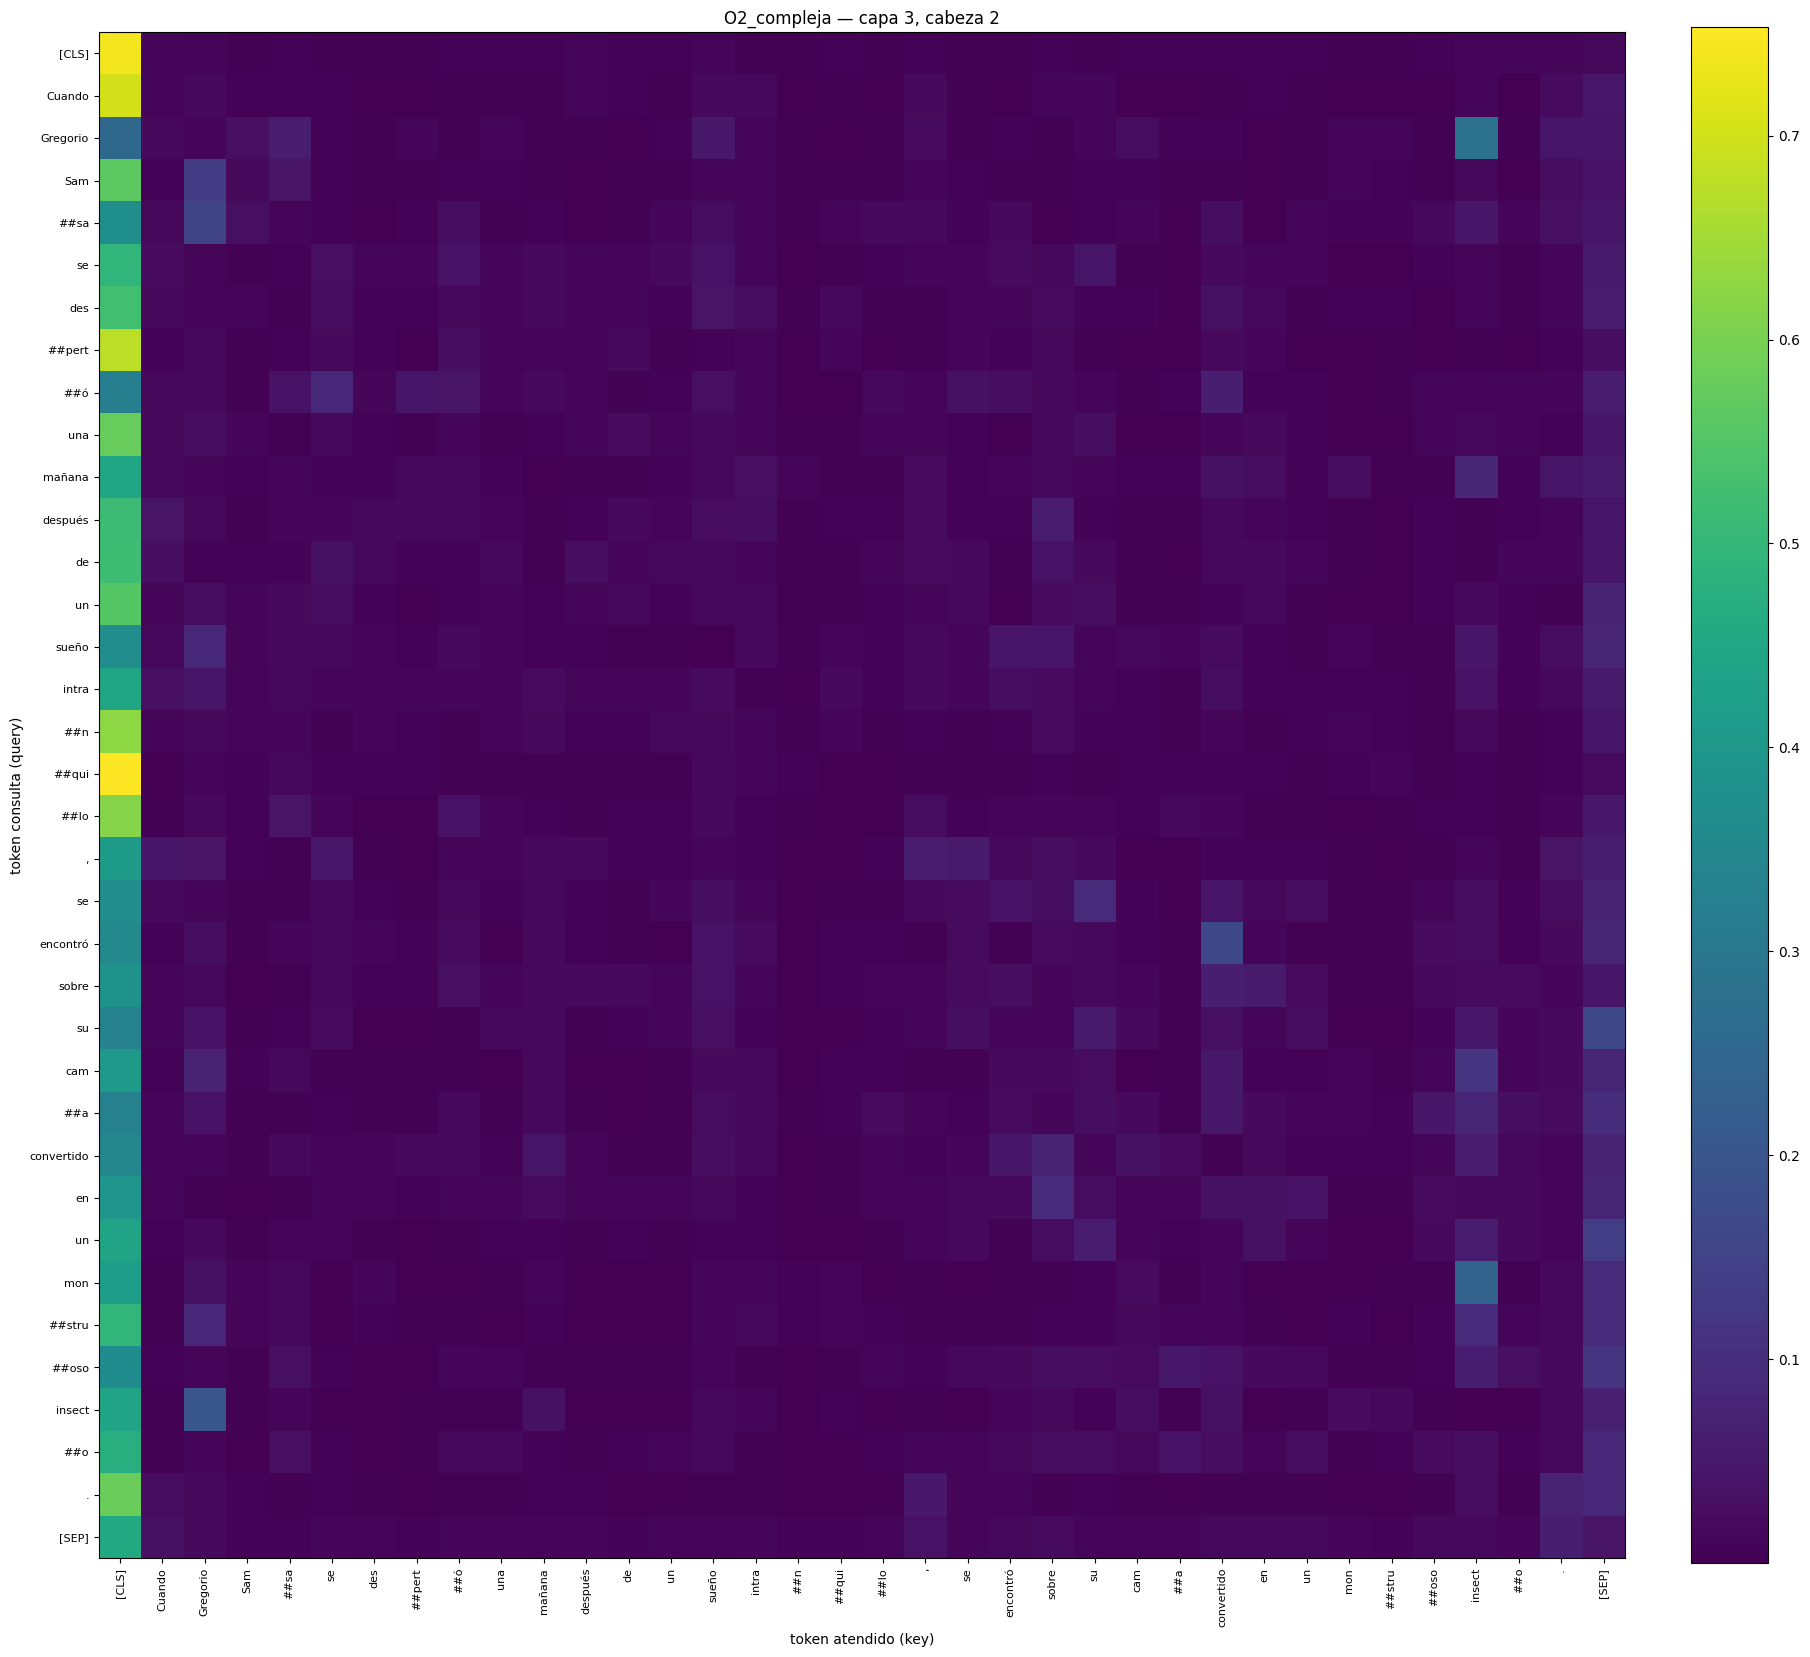

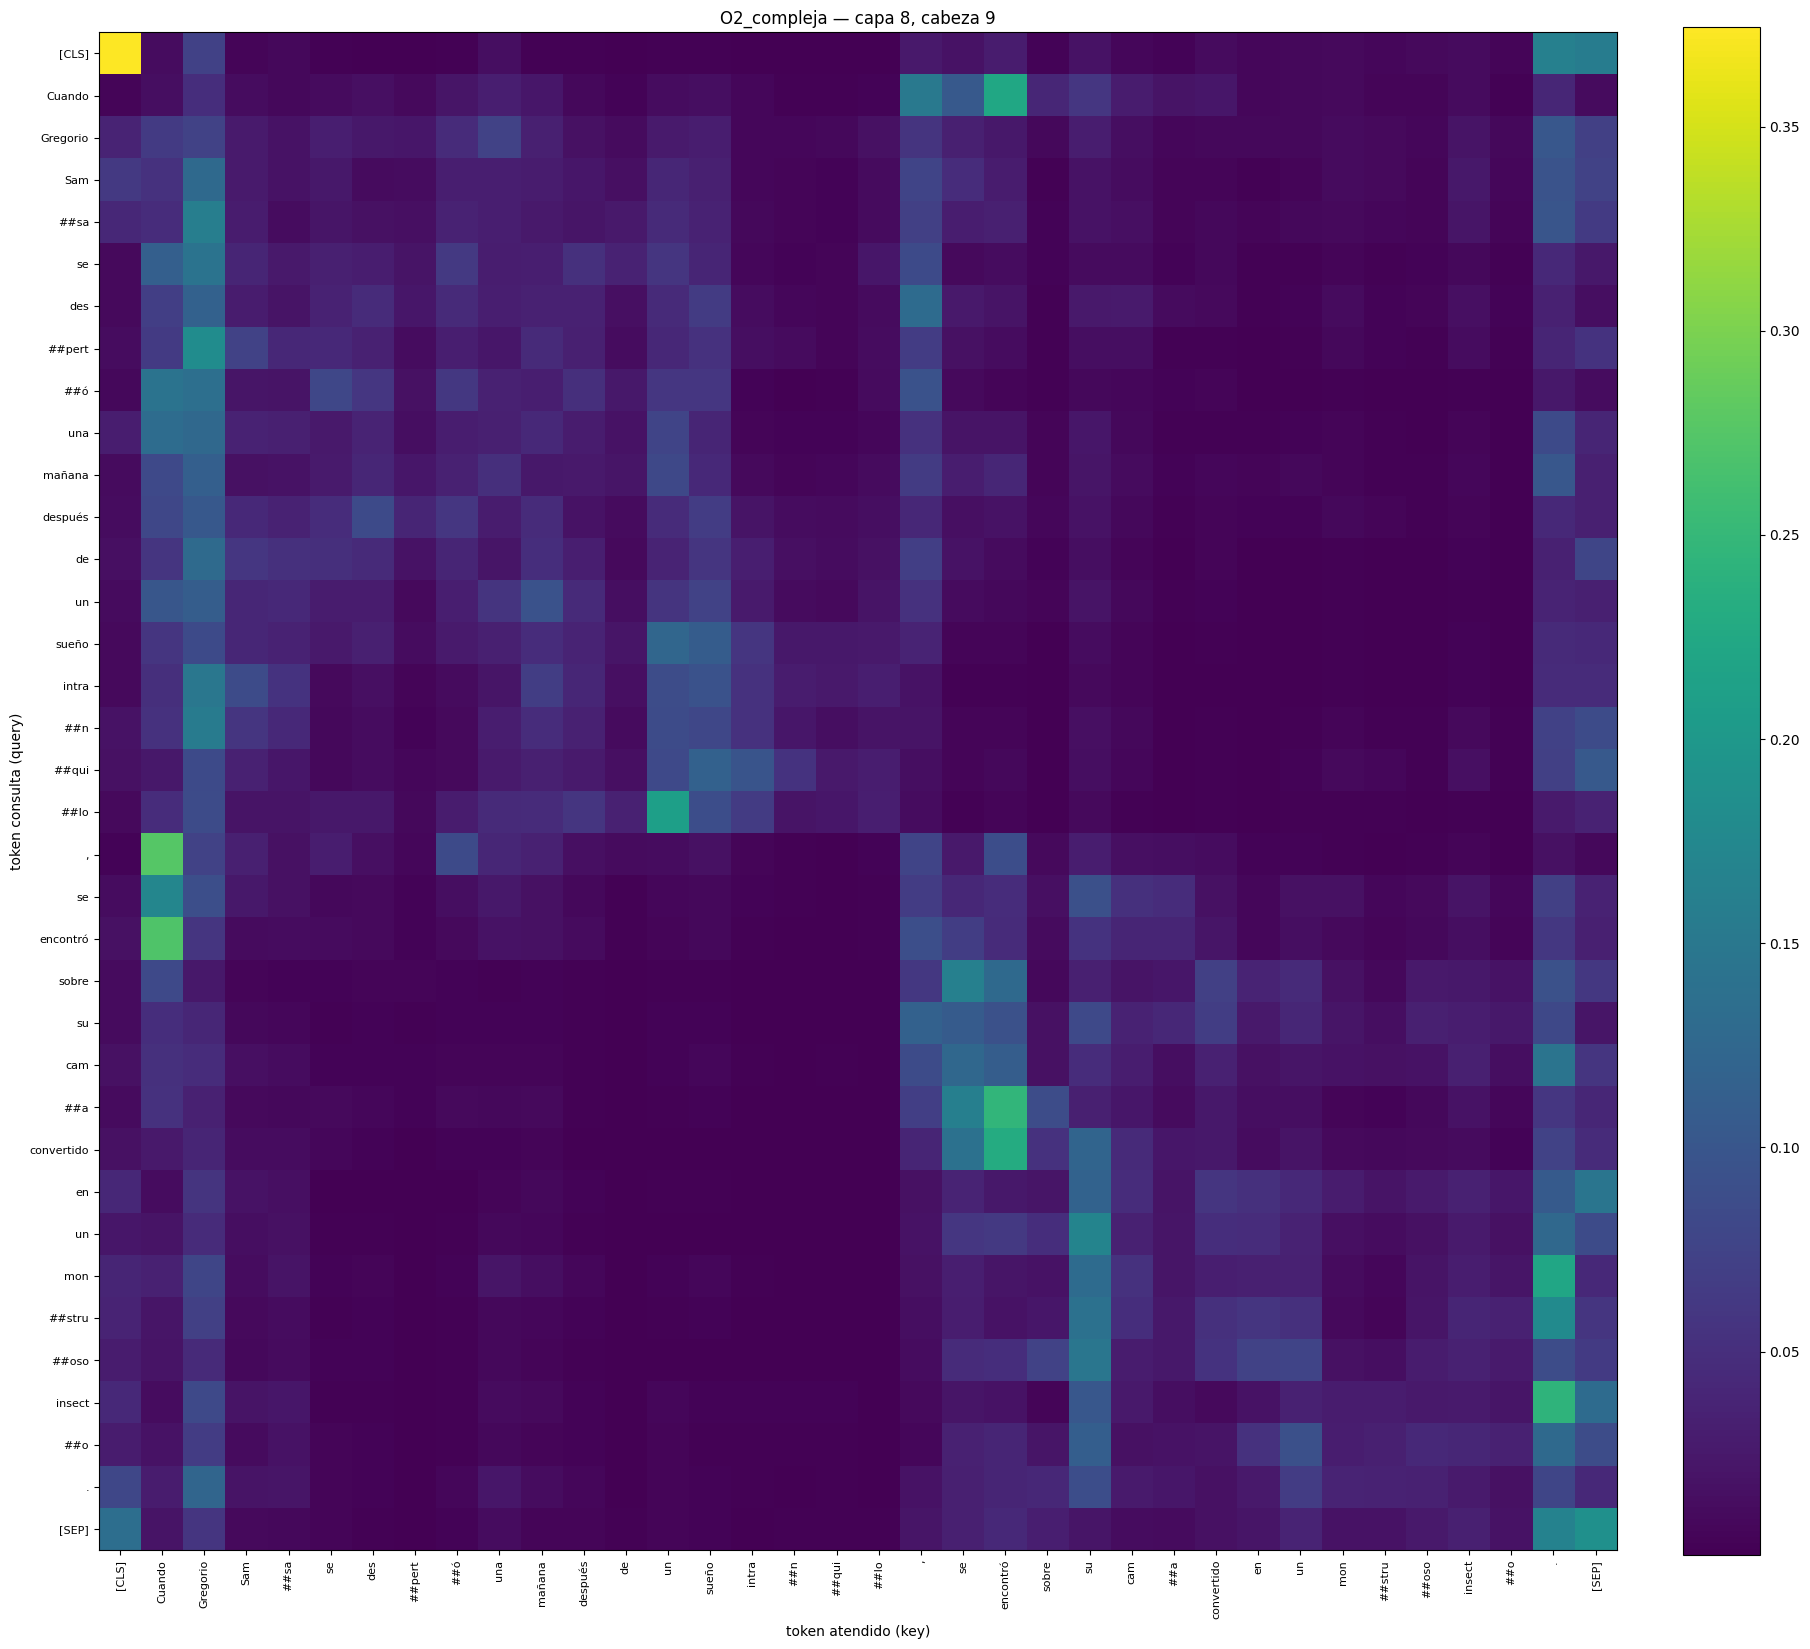

In [12]:
# Mapa de calor de una matriz de atención (capa/cabeza a elección) para evidencia visual.
def heatmap(nombre_oracion, capa, cabeza):
    att, tk = attn_cache[nombre_oracion]
    M = att[capa][0, cabeza].cpu().numpy()
    fig, ax = plt.subplots(figsize=(0.45 * len(tk) + 2, 0.45 * len(tk) + 2))
    im = ax.imshow(M, cmap='viridis')
    ax.set_xticks(range(len(tk))); ax.set_xticklabels(tk, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tk))); ax.set_yticklabels(tk, fontsize=8)
    ax.set_xlabel('token atendido (key)'); ax.set_ylabel('token consulta (query)')
    ax.set_title(f'{nombre_oracion} — capa {capa}, cabeza {cabeza}')
    fig.colorbar(im, fraction=0.046, pad=0.04)
    plt.tight_layout(); plt.show()

heatmap('O2_compleja', 3, 2)
heatmap('O2_compleja', 8, 9)

## Parte D · Comparación entre oraciones

Contraste con una palabra ambigua: **"banco"** en dos contextos.

```
El banco aprobó el préstamo.       (institución financiera)
Me senté en el banco del parque.   (asiento)

In [13]:
def comparar_token(palabra, oraciones_lista, capas=CAPAS, cabezas=CABEZAS, k=5):
    filas = []
    for nombre in oraciones_lista:
        att, tk = attn_cache[nombre]
        idxs = indices_de_palabra(tk, palabra)
        for capa in capas:
            for cabeza in cabezas:
                top = top_atencion(att, tk, capa, cabeza, idxs, k=k)
                filas.append({
                    'oracion': nombre,
                    'palabra': palabra,
                    'capa': capa, 'cabeza': cabeza,
                    'top5': ', '.join(f'{t}({p})' for t, p in top),
                })
    return pd.DataFrame(filas)

tabla_D_banco = comparar_token('banco', ['B1_banco_finanzas', 'B2_banco_parque'])
display(tabla_D_banco)

,oracion,palabra,capa,cabeza,top5
0,B1_banco_finanzas,banco,3,2,"[CLS](0.5374), [SEP](0.1992), ##robó(0.085), ...."
1,B1_banco_finanzas,banco,3,9,"banco(0.7054), [SEP](0.1763), .(0.0686), [CLS]..."
2,B1_banco_finanzas,banco,8,2,"[SEP](0.3655), banco(0.2298), El(0.2264), .(0...."
3,B1_banco_finanzas,banco,8,9,"##robó(0.1795), .(0.1679), [SEP](0.1528), el(0..."
4,B2_banco_parque,banco,3,2,"[CLS](0.3635), parque(0.2298), [SEP](0.1461), ..."
5,B2_banco_parque,banco,3,9,"banco(0.7491), [SEP](0.1149), .(0.0746), parqu..."
6,B2_banco_parque,banco,8,2,"parque(0.3712), banco(0.2359), el(0.1426), del..."
7,B2_banco_parque,banco,8,9,"Me(0.1958), en(0.1544), sent(0.1411), ##é(0.11..."


In [14]:
# Simple vs compleja: el token "Gregorio" / "mirada" en O1 vs el sujeto en O2.
tabla_D_simple_vs_compleja = pd.concat([
    comparar_token('mirada', ['O1_simple']),
    comparar_token('despertó', ['O2_compleja']),
], ignore_index=True)
display(tabla_D_simple_vs_compleja)

# Distancia media a la que atiende cada cabeza (¿atención local o de largo alcance?).
def distancia_media_atencion(nombre, capa, cabeza):
    att, tk = attn_cache[nombre]
    M = att[capa][0, cabeza].cpu().numpy()
    n = M.shape[0]
    pos = np.arange(n)
    d = np.abs(pos[:, None] - pos[None, :])
    return float((M * d).sum() / M.sum())

filas = []
for nombre in ['O1_simple', 'O2_compleja', 'O3_compleja']:
    for capa in CAPAS:
        for cabeza in CABEZAS:
            filas.append({'oracion': nombre, 'capa': capa, 'cabeza': cabeza,
                          'distancia_media_atencion': round(distancia_media_atencion(nombre, capa, cabeza), 2)})
display(pd.DataFrame(filas))

,oracion,palabra,capa,cabeza,top5
0,O1_simple,mirada,3,2,"[CLS](0.5042), [SEP](0.1509), Gregorio(0.0899)..."
1,O1_simple,mirada,3,9,"##da(0.385), mira(0.3647), [SEP](0.1023), .(0...."
2,O1_simple,mirada,8,2,"mira(0.2372), Gregorio(0.1625), La(0.1139), ha..."
3,O1_simple,mirada,8,9,"Gregorio(0.1698), .(0.1062), de(0.1022), La(0...."
4,O2_compleja,despertó,3,2,"[CLS](0.5087), [SEP](0.0483), se(0.0423), conv..."
5,O2_compleja,despertó,3,9,"des(0.3164), ##pert(0.2912), ##ó(0.2505), [SEP..."
6,O2_compleja,despertó,8,2,"Gregorio(0.4133), Sam(0.1189), ##sa(0.1116), s..."
7,O2_compleja,despertó,8,9,"Gregorio(0.145), ,(0.0972), Cuando(0.0918), su..."


,oracion,capa,cabeza,distancia_media_atencion
0,O1_simple,3,2,5.76
1,O1_simple,3,9,1.87
2,O1_simple,8,2,3.65
3,O1_simple,8,9,4.90
4,O2_compleja,3,2,13.83
5,O2_compleja,3,9,4.46
6,O2_compleja,8,2,10.45
7,O2_compleja,8,9,9.69
8,O3_compleja,3,2,12.17
9,O3_compleja,3,9,4.16


In [15]:
# Guardar tablas como evidencia (entregable).
tabla_C.to_csv('tabla_atencion_parteC.csv', index=False, encoding='utf-8')
tabla_D_banco.to_csv('tabla_atencion_parteD_banco.csv', index=False, encoding='utf-8')
tabla_D_simple_vs_compleja.to_csv('tabla_atencion_parteD_simple_vs_compleja.csv', index=False, encoding='utf-8')
resumen.to_csv('tabla_tokenizacion.csv', index=False, encoding='utf-8')
print('CSV guardados:')
print(' - tabla_tokenizacion.csv')
print(' - tabla_atencion_parteC.csv')
print(' - tabla_atencion_parteD_banco.csv')
print(' - tabla_atencion_parteD_simple_vs_compleja.csv')

CSV guardados:
 - tabla_tokenizacion.csv
 - tabla_atencion_parteC.csv
 - tabla_atencion_parteD_banco.csv
 - tabla_atencion_parteD_simple_vs_compleja.csv
